In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv('../data/processed/returns_computed.csv')

risk_df = (
    nav.groupby('amfi_code')['daily_returns']
       .apply(
           lambda x: pd.Series({
               'VaR_95': x.quantile(0.05), 
               'CVaR_95': x[x <= x.quantile(0.05)].mean()
           })
       )
       .reset_index()
)
risk_df.to_csv('../data/processed/var_cvar_report.csv')

In [42]:
counts = nav.groupby('amfi_code')['date'].count().sort_values(ascending=False)
print(counts.head(10)) 

fund_codes = counts.head(5).index.tolist()
print("Selected funds:", fund_codes)

amfi_code
100016    1150
100025    1150
100033    1150
101206    1150
101207    1150
101208    1150
102885    1150
102886    1150
102887    1150
118632    1150
Name: date, dtype: int64
Selected funds: [100016, 100025, 100033, 101206, 101207]


In [41]:
nav_5 = nav[nav['amfi_code'].isin(fund_codes)]

nav_wide = nav_5.pivot(index='date', columns='amfi_code', values='nav')
nav_wide = nav_wide.sort_index()

print(nav_wide.shape)
nav_wide.head()

(1150, 5)


amfi_code,100016,100025,100033,101206,101207
date,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845


In [43]:
ret = nav_wide.pct_change().dropna()

In [44]:
rolling_sharpe = ret.rolling(90).mean() / ret.rolling(90).std() * np.sqrt(252)
rolling_sharpe = rolling_sharpe.dropna()

print(rolling_sharpe.shape)
rolling_sharpe.head()

(1060, 5)


amfi_code,100016,100025,100033,101206,101207
date,,,,,
2022-05-09,-0.064787,2.408256,-1.555736,0.564926,1.173633
2022-05-10,-0.058880,2.629797,-1.482050,0.697009,0.885005
2022-05-11,-0.532521,2.638858,-1.651757,0.514095,0.771553
2022-05-12,-0.649005,2.699504,-1.647560,0.726067,1.137632
2022-05-13,-0.498278,2.663579,-1.340969,0.634676,0.719704


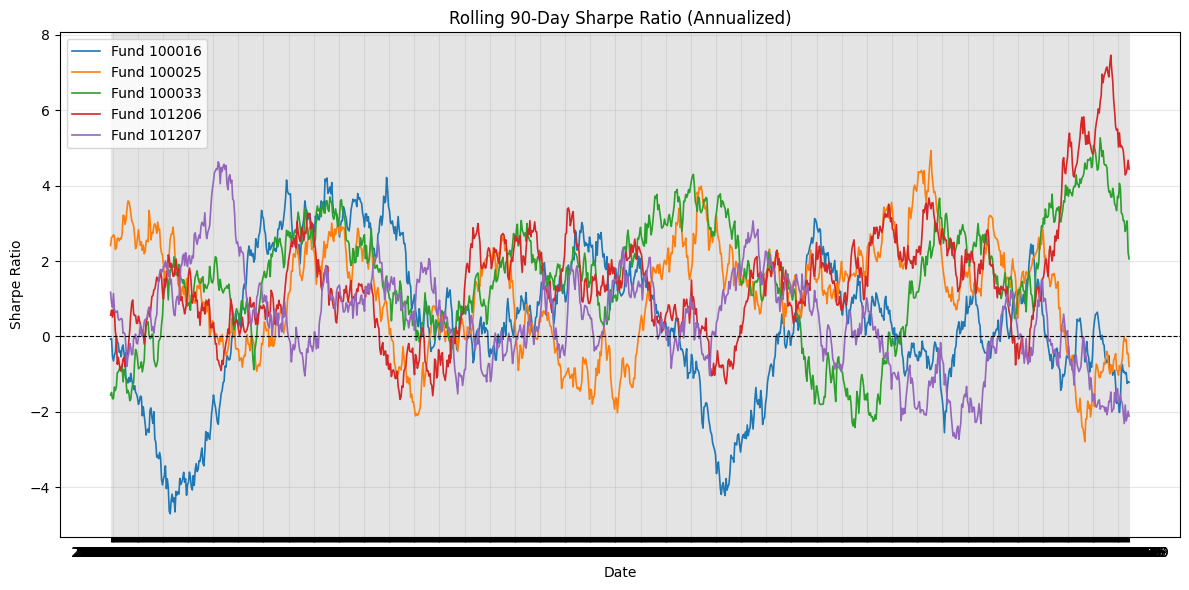

In [47]:
plt.figure(figsize=(12, 6))
for col in rolling_sharpe.columns:
    plt.plot(rolling_sharpe.index, rolling_sharpe[col], label=f"Fund {col}", linewidth=1.2)

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Rolling 90-Day Sharpe Ratio (Annualized)")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rolling sharp chart.png')
plt.show()

In [53]:
invest = pd.read_csv('../data/processed/clean_investor_transactions.csv', parse_dates=['transaction_date'])
invest.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [56]:
first_txn = invest.groupby('investor_id')['transaction_date'].min().reset_index()
first_txn['cohort_year'] = first_txn['transaction_date'].dt.year
first_txn = first_txn.rename(columns={'transaction_date': 'first_transaction_date'})

print(first_txn['cohort_year'].value_counts())

invest = invest.merge(first_txn[['investor_id', 'cohort_year']], on='investor_id', how='left')


cohort_year
2024    4803
2025     197
Name: count, dtype: int64


In [57]:
sip_data = invest[invest['transaction_type'] == 'SIP']
avg_sip_by_cohort = sip_data.groupby('cohort_year')['amount_inr'].mean()
print("\nAverage SIP amount by cohort:")
print(avg_sip_by_cohort)


Average SIP amount by cohort:
cohort_year
2024    10996.885825
2025    13505.209581
Name: amount_inr, dtype: float64


In [58]:
inflow_data = invest[invest['transaction_type'].isin(['SIP', 'LUMPSUM'])]
total_invested_by_cohort = inflow_data.groupby('cohort_year')['amount_inr'].sum()
print("\nTotal invested by cohort (SIP + LUMPSUM):")
print(total_invested_by_cohort)


Total invested by cohort (SIP + LUMPSUM):
cohort_year
2024    2258062304
2025      18992635
Name: amount_inr, dtype: int64


In [59]:
fund_preference = (
    inflow_data
    .groupby(['cohort_year', 'amfi_code'])['amount_inr']
    .sum()
    .reset_index()
)
top_funds_by_cohort = (
    fund_preference
    .sort_values(['cohort_year', 'amount_inr'], ascending=[True, False])
    .groupby('cohort_year')
    .head(5)
)
print("\nTop 5 preferred funds (by amfi_code) per cohort:")
print(top_funds_by_cohort)


Top 5 preferred funds (by amfi_code) per cohort:
    cohort_year  amfi_code  amount_inr
17         2024     119095    65025476
6          2024     102885    64871167
35         2024     148568    64756484
19         2024     119551    61947551
27         2024     120507    61485476
56         2025     119094     1283425
62         2025     119599     1194798
44         2025     101207     1024070
71         2025     120844     1013707
78         2025     149323      987002


In [61]:
summary = pd.DataFrame({
    'avg_sip_amount': avg_sip_by_cohort,
    'total_invested': total_invested_by_cohort,
    'num_investors': first_txn.groupby('cohort_year')['investor_id'].count()
})
print("\nCohort Summary:")
print(summary)

summary.to_csv('../data/processed/cohort_analysis_summary.csv')


Cohort Summary:
             avg_sip_amount  total_invested  num_investors
cohort_year                                               
2024           10996.885825      2258062304           4803
2025           13505.209581        18992635            197


In [68]:
sip = invest[invest['transaction_type'] == 'SIP'].copy()
sip = sip.sort_values(['investor_id', 'transaction_date'])

sip_counts = sip.groupby('investor_id')['transaction_date'].count()
eligible_investors = sip_counts[sip_counts >= 6].index

sip_eligible = sip[sip['investor_id'].isin(eligible_investors)].copy()

sip_eligible['gap_days'] = (
    sip_eligible.groupby('investor_id')['transaction_date'].diff().dt.days
)

avg_gap = (
    sip_eligible.groupby('investor_id')['gap_days']
    .mean()
    .reset_index()
    .rename(columns={'gap_days': 'avg_gap_days'})
)

avg_gap['at_risk'] = avg_gap['avg_gap_days'] > 35

print(avg_gap.head(10))
print("\nNumber of at-risk investors:", avg_gap['at_risk'].sum())
print("Total eligible investors (6+ SIPs):", len(avg_gap))

avg_gap.to_csv('../data/processed/sip_continuation_analysis.csv', index=False)


  investor_id  avg_gap_days  at_risk
0   INV000004     85.400000     True
1   INV000008     70.400000     True
2   INV000010     64.800000     True
3   INV000011     40.166667     True
4   INV000012     57.000000     True
5   INV000013     55.333333     True
6   INV000014     75.333333     True
7   INV000023     58.571429     True
8   INV000028     93.600000     True
9   INV000029     60.666667     True

Number of at-risk investors: 1332
Total eligible investors (6+ SIPs): 1362


In [74]:
port = pd.read_csv('../data/processed/clean_portfolio_holdings.csv')

sector_weights = (
    port.groupby(['amfi_code', 'sector'])['weight_pct']
    .sum()
    .reset_index()
)

sector_weights['weight_sq'] = sector_weights['weight_pct'] ** 2

hhi = (
    sector_weights.groupby('amfi_code')['weight_sq']
    .sum()
    .reset_index()
    .rename(columns={'weight_sq': 'hhi'})
)

hhi['hhi_normalized'] = hhi['hhi'] / 10000

def concentration_label(h):
    if h < 1500:
        return 'Diversified'
    elif h < 2500:
        return 'Moderately Concentrated'
    else:
        return 'Highly Concentrated'

hhi['concentration'] = hhi['hhi'].apply(concentration_label)

hhi = hhi.sort_values('hhi', ascending=False).reset_index(drop=True)

hhi.to_csv('../data/processed/sector_hhi.csv', index=False)

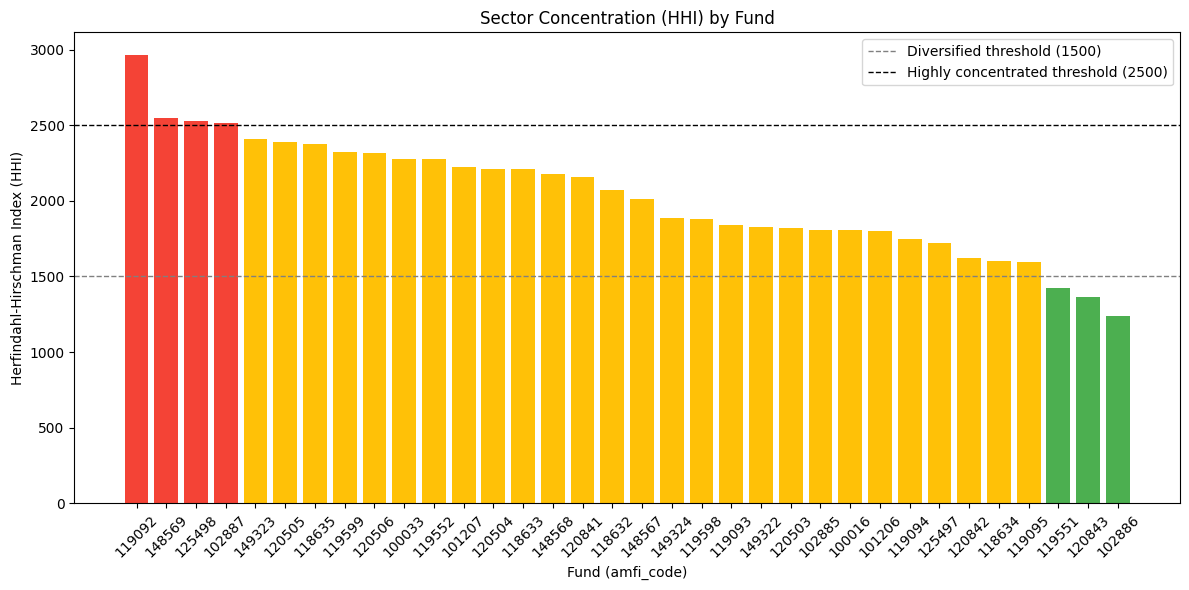

In [75]:
plt.figure(figsize=(12, 6))
colors = hhi['concentration'].map({
    'Diversified': '#4CAF50',
    'Moderately Concentrated': '#FFC107',
    'Highly Concentrated': '#F44336'
})

plt.bar(hhi['amfi_code'].astype(str), hhi['hhi'], color=colors)
plt.axhline(1500, color='gray', linestyle='--', linewidth=1, label='Diversified threshold (1500)')
plt.axhline(2500, color='black', linestyle='--', linewidth=1, label='Highly concentrated threshold (2500)')

plt.title("Sector Concentration (HHI) by Fund")
plt.xlabel("Fund (amfi_code)")
plt.ylabel("Herfindahl-Hirschman Index (HHI)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('sector_hhi_chart.png', dpi=150)
plt.show()

In [80]:
pd.read_csv('../data/processed/var_cvar_report.csv')

,Unnamed: 0,amfi_code,level_1,daily_returns
0,0,100016,VaR_95,-0.014364
1,1,100016,CVaR_95,-0.018060
2,2,100025,VaR_95,-0.003793
3,3,100025,CVaR_95,-0.004994
4,4,100033,VaR_95,-0.019034
...,...,...,...,...
75,75,149322,CVaR_95,-0.018402
76,76,149323,VaR_95,-0.017882
77,77,149323,CVaR_95,-0.022607
78,78,149324,VaR_95,-0.023483


# Key Insights

**1. Sector Concentration Risk is Widespread**
Out of 34 equity funds analyzed, only 3 funds (119551, 120843, 102886) qualify as "Diversified" (HHI < 1500), while 4 funds are "Highly Concentrated" (HHI > 2500). Fund 119092 is the most concentrated overall (HHI = 2,967.7), and Fund 102886 is the most diversified (HHI = 1,240.2) — indicating that most portfolios in this universe carry significant single-sector exposure rather than broad diversification.

**2. Risk-Adjusted Performance Varies Sharply Across Funds**
Among the funds tracked, Fund 100025 stands out with a strongly positive rolling 90-day Sharpe ratio (~2.66), reflecting consistently good risk-adjusted returns. In contrast, Fund 100033 shows a persistently negative Sharpe ratio (~-1.34), suggesting its returns have not compensated investors for the volatility taken on — a candidate for review or investor caution.

**3. Tail Risk (VaR) is Highest in Small/Mid-Cap-Oriented Funds**
Fund 149324 shows the highest downside risk among funds analyzed, with a 95% VaR of -2.35% (CVaR of -3.10%) — meaning on its worst 5% of days, losses can exceed 2.35% in a single day. Fund 100025, by contrast, has one of the lowest VaR values (-0.38%), reinforcing its profile as a comparatively low-risk, high-Sharpe fund.

**4. The 2025 Investor Cohort Commits Larger SIP Amounts**
New investors acquired in 2025 invest ~23% more per SIP on average (₹13,505) compared to the 2024 cohort (₹10,997). However, the 2024 cohort remains dominant in scale — 4,803 investors contributing ₹225.8 crore in total invested capital, versus 197 investors and ₹1.9 crore for 2025 (partly reflecting 2025 still being early in the dataset).

**5. A Large Share of Regular SIP Investors Show Continuation Risk**
Of the 1,362 investors with 6+ SIP transactions, the large majority are flagged "at-risk" — averaging gaps greater than 35 days between SIP installments (sampled average gaps range from ~40 to ~85 days). This signals that even "regular" SIP investors frequently deviate from a strict monthly cadence, representing a meaningful retention and engagement opportunity.